In [ ]:
!pip install GEOparse

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import GEOparse

In [ ]:
gse=GEOparse.get_GEO("GSE6613",destdir="./")

30-Aug-2026 13:22:53 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
30-Aug-2026 13:22:53 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
30-Aug-2026 13:22:53 INFO GEOparse - Parsing ./GSE6613_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE6613_family.soft.gz: 
30-Aug-2026 13:22:53 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
30-Aug-2026 13:22:53 DEBUG GEOparse - SERIES: GSE6613
DEBUG:GEOparse:SERIES: GSE6613
30-Aug-2026 13:22:53 DEBUG GEOparse - PLATFORM: GPL96
DEBUG:GEOparse:PLATFORM: GPL96
30-Aug-2026 13:22:54 DEBUG GEOparse - SAMPLE: GSM153404
DEBUG:GEOparse:SAMPLE: GSM153404
30-Aug-2026 13:22:54 DEBUG GEOparse - SAMPLE: GSM153405
DEBUG:GEOparse:SAMPLE: GSM153405
30-Aug-2026 13:22:54 DEBUG GEOparse - SAMPLE: GSM153406
DEBUG:GEOparse:SAMPLE: GSM153406
30-Aug-2026 13:22:54 DEBUG GEOparse - SAMPLE: GSM153407
DEBUG:GEOparse:SAMPLE: GSM153407
3

In [ ]:
samples=gse.pivot_samples("VALUE")
print(samples.shape)

(22283, 105)


In [ ]:
df=samples.T
print(df.shape)

(105, 22283)


In [ ]:
probe_to_gene={}
gpl = gse.gpls[list(gse.gpls.keys())[0]]
print(gpl.table.columns)

for i in range(0,len(gpl.table)):
    probe_id=gpl.table["ID"].iloc[i]
    gene_symbol=gpl.table["Gene Symbol"].iloc[i]
    probe_to_gene[probe_id]= gene_symbol
#probe_to_gene = dict(zip(gpl.table["ID"], gpl.table["Gene Symbol"]))

Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')


In [ ]:
s=probe_to_gene['121_at']
print(s)

PAX8


In [ ]:
gpl.table[gpl.table["ID"] == "AFFX-r2-Ec-bioD-3_at"]

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
22267,AFFX-r2-Ec-bioD-3_at,NaN,--Control,Homo sapiens,"Oct 6, 2014",Control sequence,Affymetrix Proprietary Database,E. coli /GEN=bioD /DB_XREF=gb:J04423.1 /NOTE=S...,AFFX-r2-Ec-bioD-3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.values
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X) #new_value = (old_value - mean_of_that_column) / std_of_that_column

<Axes: >

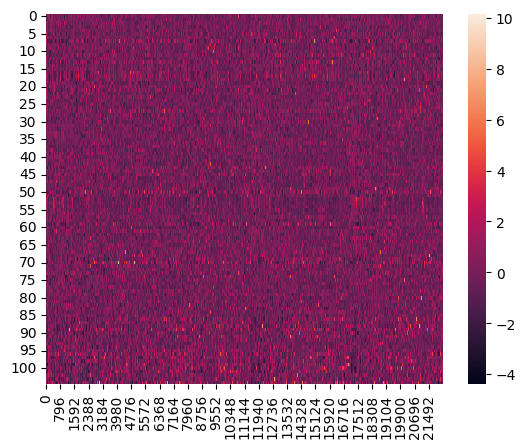

In [ ]:
sb.heatmap(X_scaled)

In [ ]:
print(X_scaled.mean(axis=0))

[ 3.34124263e-16 -2.22044605e-16 -4.58693929e-16 ...  7.19001578e-17
  1.86094526e-16 -6.76707367e-17]


In [ ]:
number_of_samples,number_of_features =X_scaled.shape
n_components_full=min(number_of_samples-1,number_of_features)
print(n_components_full)

104


In [ ]:
from sklearn.decomposition import PCA
pca_full=PCA(n_components_full,random_state=2020)
pca_full.fit(X_scaled)

PCA(n_components=104, random_state=2020)

In [ ]:
print("Total Variance explained:", sum(pca_full.explained_variance_ratio_ * 100))

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_ * 100)
print(cumulative_variance)


Total Variance explained: 100.00000000000001
[ 10.06817218  14.82374052  17.81848881  20.6642583   23.40689657
  25.81068557  27.95200436  29.81057292  31.49975861  33.1268589
  34.7310336   36.23502112  37.6901624   39.12654918  40.52524348
  41.82538412  43.09176678  44.28282854  45.44357343  46.56161883
  47.65278401  48.72124088  49.7743057   50.78486909  51.78938886
  52.76931432  53.72462518  54.67221267  55.60576897  56.51838561
  57.40910094  58.28387899  59.15142996  60.00731559  60.85089523
  61.68975499  62.50336079  63.30800318  64.09902963  64.8760774
  65.64637442  66.40951752  67.1684646   67.91398506  68.65079268
  69.38003153  70.10030048  70.81428412  71.5129946   72.20361941
  72.89340507  73.57703308  74.25980214  74.92610963  75.58841111
  76.24040769  76.88730721  77.52867414  78.16653892  78.79940764
  79.42211369  80.03906383  80.6521856   81.2580927   81.85430513
  82.44477605  83.02593379  83.60027968  84.17151215  84.73863866
  85.29517815  85.84351767  86.38

In [ ]:
pca_95=PCA(n_components=0.95,random_state=2020)
pca_95.fit(X_scaled)
X_pca_95 = pca_95.transform(X_scaled)
X_pca_95.shape

(105, 91)

Text(0, 0.5, 'Transformed Data')

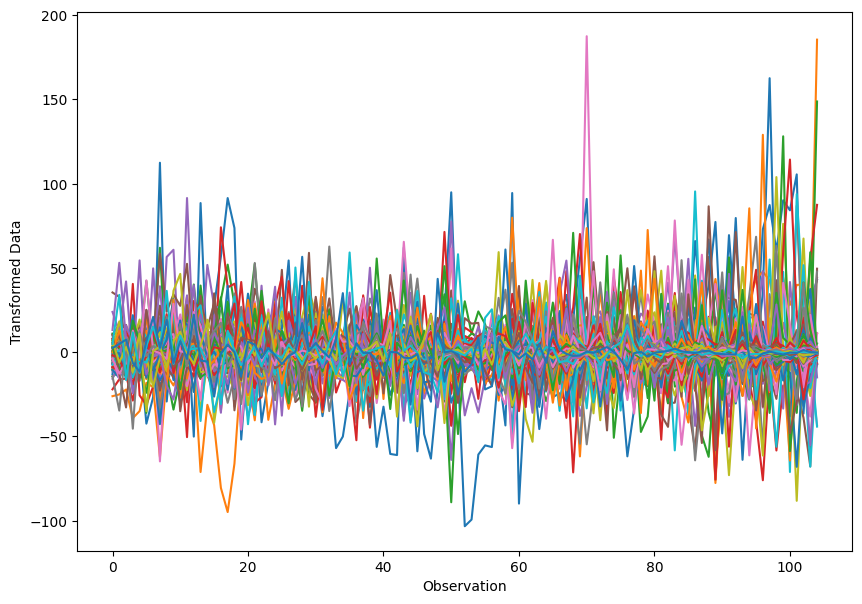

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(X_pca_95)
plt.xlabel('Observation')
plt.ylabel('Transformed Data')

In [ ]:

index_list=[]
for pc in df.columns:
    index_list.append(pc)
print(index_list)
col = []
for i in range(1, pca_full.n_components_ + 1):
    col.append("PC" + str(i))
print(col)

loadings=pd.DataFrame(pca_full.components_.T,columns=col,index=index_list)
loadings

['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at', '1316_at', '1320_at', '1405_i_at', '1431_at', '1438_at', '1487_at', '1494_f_at', '1598_g_at', '160020_at', '1729_at', '1773_at', '177_at', '179_at', '1861_at', '200000_s_at', '200001_at', '200002_at', '200003_s_at', '200004_at', '200005_at', '200006_at', '200007_at', '200008_s_at', '200009_at', '200010_at', '200011_s_at', '200012_x_at', '200013_at', '200014_s_at', '200015_s_at', '200016_x_at', '200017_at', '200018_at', '200019_s_at', '200020_at', '200021_at', '200022_at', '200023_s_at', '200024_at', '200025_s_at', '200026_at', '200027_at', '200028_s_at', '200029_at', '200030_s_at', '200031_s_at', '200032_s_at', '200033_at', '200034_s_at', '200035_at', '200036_s_at', '200037_s_at', '200038_s_at', '200039_s_at', '200040_at', '200041_s_at', '200042_at', '200043_at', '200044_at', '200045_at', '200046_at', '200047_s_at', '200048_s_at', '200049_at', '200050_at', '200051_at', '200052_s_at', '200053_at', '200054_at', '200055_

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC95,PC96,PC97,PC98,PC99,PC100,PC101,PC102,PC103,PC104
1007_s_at,0.004087,-0.009748,-0.000679,-0.006922,-0.006019,-0.004859,-0.003288,0.012282,-0.002690,0.007224,...,0.006498,0.001623,-0.008684,-0.002823,0.004978,0.008609,0.006501,0.003389,-0.000941,0.003304
1053_at,-0.000809,0.011194,-0.008294,0.007815,-0.005157,-0.009646,-0.000092,0.001809,-0.005704,-0.002260,...,-0.004869,-0.004985,0.004248,-0.001575,-0.006125,-0.006075,0.005998,0.006869,0.004302,0.011701
117_at,-0.004255,0.000650,-0.008836,0.019617,0.005204,0.009374,0.002829,-0.002837,-0.004745,0.011312,...,-0.001148,0.009711,-0.004045,-0.005371,0.004541,0.001612,-0.005556,0.001895,0.003555,-0.009567
121_at,0.012554,-0.011300,-0.004688,-0.006679,-0.004564,0.000372,-0.007946,0.001417,-0.001967,-0.009469,...,0.000379,-0.007682,-0.000178,0.004579,0.003336,0.006559,0.000610,-0.001079,0.002038,0.000956
1255_g_at,0.007895,0.016200,0.000635,-0.001962,0.001270,0.000406,0.004473,0.006257,0.003909,0.001501,...,0.002401,-0.005022,0.001705,-0.000713,-0.005058,-0.004702,-0.005707,0.006397,0.000683,-0.003099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AFFX-r2-Hs28SrRNA-3_at,0.008204,0.011590,-0.004343,-0.009510,0.014447,0.004580,-0.005968,-0.013338,-0.013173,-0.004003,...,0.000282,0.000317,-0.002301,-0.002238,0.003292,0.000566,-0.002434,0.000086,-0.002938,-0.000449
AFFX-r2-Hs28SrRNA-5_at,0.005253,0.004055,-0.003124,-0.006489,0.021350,0.005274,-0.001495,-0.006079,0.003404,-0.000728,...,0.003053,0.001618,0.000638,-0.005387,-0.000183,0.000737,-0.009588,0.004293,0.003269,-0.003606
AFFX-r2-Hs28SrRNA-M_at,0.009782,0.015603,-0.004199,-0.010090,0.010595,-0.000518,-0.000684,-0.005203,0.002981,-0.006162,...,-0.005369,0.005375,-0.000237,-0.005577,-0.003874,-0.003969,0.000940,0.000880,0.002676,-0.000386
AFFX-r2-P1-cre-3_at,0.011302,0.022608,0.003135,0.002292,0.001110,-0.006797,-0.008613,-0.003839,-0.001723,0.002583,...,-0.001974,-0.001869,0.000676,0.000077,-0.000316,0.000242,-0.000171,-0.001353,-0.000453,-0.001577


In [ ]:
def top_genes_by_pca_weighting(loadings_df,pca_model,n_pcs,probe_to_gene, top_n=20):
    abs_loadings= loadings_df.iloc[:,:n_pcs].abs()
    variance_ratio=pca_model.explained_variance_ratio_[:n_pcs]
    gene_scores = pd.Series (0.0,index=abs_loadings.index)
    i=0

    for name,data in abs_loadings.items():
        gene_scores=gene_scores+ data*variance_ratio[i]
        i=i+1

    result = pd.DataFrame({
        "ProbeID":gene_scores.index,
        "GeneSymbol":[probe_to_gene.get(pid,"Unknown")for pid in gene_scores.index],
        "Score": gene_scores.values
        }).sort_values("Score", ascending=False).reset_index(drop=True)
    return result.head(top_n)




In [ ]:
top20_pc5 = top_genes_by_pca_weighting(
    loadings, pca_full, n_pcs=5,
    probe_to_gene=probe_to_gene, top_n=20
)
top20_pc5

,ProbeID,GeneSymbol,Score
0,200912_s_at,EIF4A2 /// MIR1248 /// SNORA4 /// SNORA63 /// ...,0.002783
1,204020_at,PURA,0.002721
2,AFFX-r2-Ec-bioD-3_at,NaN,0.002690
3,200627_at,PTGES3,0.002689
4,200063_s_at,NPM1,0.002673
5,201051_at,ANP32A,0.002657
6,221199_at,GFRA4,0.002645
7,200858_s_at,RPS8 /// SNORD38B /// SNORD55,0.002614
8,211699_x_at,HBA1 /// HBA2,0.002611
9,217232_x_at,HBB,0.002607


In [ ]:
top20_pc10 = top_genes_by_pca_weighting(
    loadings, pca_full, n_pcs=10,
    probe_to_gene=probe_to_gene, top_n=20
)
top20_pc10

,ProbeID,GeneSymbol,Score
0,211165_x_at,EPHB2,0.003287
1,221199_at,GFRA4,0.003282
2,215733_x_at,CTAG2,0.003234
3,216410_at,CNN3P1 /// CNN3P1,0.003232
4,210165_at,DNASE1,0.003224
5,206428_s_at,NaN,0.003221
6,211448_s_at,RGS6,0.003218
7,211915_s_at,TUBB7P,0.003215
8,219652_s_at,CXorf36,0.003180
9,220006_at,EFCC1,0.003174


In [ ]:
genes_5 = set(top20_pc5["GeneSymbol"])
genes_10 = set(top20_pc10["GeneSymbol"])

overlap = genes_5 & genes_10
only_in_5 = genes_5 - genes_10
only_in_10 = genes_10 - genes_5

print(f"Genes in both lists: {len(overlap)}")
print(overlap)
print(f"\nOnly in top-5-PC list: {len(only_in_5)}")
print(only_in_5)
print(f"\nOnly in top-10-PC list: {len(only_in_10)}")
print(only_in_10)

comparison_df = pd.DataFrame({
    "Top-5-PC rank": pd.Series(top20_pc5["GeneSymbol"].values, index=range(1, 21)),
    "Top-10-PC rank": pd.Series(top20_pc10["GeneSymbol"].values, index=range(1, 21)),
})
comparison_df

Genes in both lists: 4
{'ARHGDIA', 'GFRA4', 'NPM1', nan}

Only in top-5-PC list: 9
{'HBB', 'PURA', 'ANP32A', 'PTGES3', 'RPS8 /// SNORD38B /// SNORD55', 'HBA1 /// HBA2', 'CDC5L', 'DCAF15', 'EIF4A2 /// MIR1248 /// SNORA4 /// SNORA63 /// SNORA81 /// SNORD2'}

Only in top-10-PC list: 14
{'PARK7', 'MAU2', 'RGS6', 'SEC14L3', 'TUBB7P', 'CTAG2', 'EPHB2', 'RHOBTB2', 'CNN3P1 /// CNN3P1', 'H3F3A /// H3F3AP4 /// H3F3B', 'SYT17', 'DNASE1', 'EFCC1', 'CXorf36'}


,Top-5-PC rank,Top-10-PC rank
1,EIF4A2 /// MIR1248 /// SNORA4 /// SNORA63 /// ...,EPHB2
2,PURA,GFRA4
3,NaN,CTAG2
4,PTGES3,CNN3P1 /// CNN3P1
5,NPM1,DNASE1
6,ANP32A,NaN
7,GFRA4,RGS6
8,RPS8 /// SNORD38B /// SNORD55,TUBB7P
9,HBA1 /// HBA2,CXorf36
10,HBB,EFCC1


Question Answers:

**Is there a difference between the two lists? Why?**

Yes there is clear difference between the two lists. Because PC1-5 captures the genes that drive the most trends or variation whereas PC6-10 captures smaller,less wide value variations.The list is made of the weights of the included PC, the 5 selected one grabs the genes driving the most variance and when PC1-10 is selected, more subtle weights push lower variance contributing genes into the spotlight.

**Is this approach suitable for gene selection?**

It works well for a initial estimation but not as a final decision.
As PCA is unsupervised, it does not consider labels while finding the most variation in the data, The deviation may as well come from noise, age, sex rather than Parkinson's Disease. It cannot differentiate between sick and healthy genes on the basis of labels.
As such supervised methods such as t-tests,differential expression between diagnosis groups are better for gene selection. Lastly, your final gene list also depends on the number of PC included in the reduction.

